In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tumor1/Training/pituitary/Tr-pi_0532.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_0282.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_1401.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_0914.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_0691.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_0972.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_0818.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_0463.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_0930.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_1354.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_0704.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_0789.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_1445.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_0605.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_0882.jpg
/kaggle/input/tumor1/Training/pituitary/Tr-pi_1274.jpg
/kaggle/in

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet152V2, DenseNet121, InceptionResNetV2
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_pre
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


2025-04-19 02:36:01.075769: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745030161.268090      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745030161.324039      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
IMG_SIZE = 224
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
label_dict = {k: v for v, k in enumerate(labels)}

def load_images(base_dir):
    X, Y = [], []
    for label in labels:
        path = os.path.join(base_dir, label)
        for img_file in tqdm(os.listdir(path), desc=f"Loading {label}"):
            img = cv2.imread(os.path.join(path, img_file))
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            Y.append(label_dict[label])
    return np.array(X), to_categorical(Y)

# Load training and testing data
X_train, Y_train = load_images('/kaggle/input/tumor1/Training')
X_test, Y_test = load_images('/kaggle/input/tumor1/Testing')

# Normalize
X_train = resnet_pre(X_train.astype(np.float32))
X_test = resnet_pre(X_test.astype(np.float32))


Loading pituitary: 100%|██████████| 300/300 [00:01<00:00, 191.38it/s]


In [4]:
def build_model(base_model):
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(4, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model


In [5]:
base = ResNet152V2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
# base = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
# base = InceptionResNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

for layer in base.layers:
    layer.trainable = False

model = build_model(base)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


I0000 00:00:1745030211.984848      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


234545216/234545216 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
early = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
check = ModelCheckpoint(filepath='best_model.keras', save_best_only=True , monitor='val_loss',
    mode='min',
    verbose=1)

history = model.fit(X_train, Y_train, validation_split=0.1, epochs=30, batch_size=32,
                    callbacks=[early, check])


Epoch 1/30


I0000 00:00:1745030249.853798      63 service.cc:148] XLA service 0x7c00081b86b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745030249.854519      63 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1745030253.164597      63 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/161 ━━━━━━━━━━━━━━━━━━━━ 1:30:48 34s/step - accuracy: 0.1562 - loss: 3.3326

I0000 00:00:1745030259.378497      63 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6312 - loss: 1.1669
Epoch 1: val_loss improved from inf to 0.45686, saving model to best_model.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 78s 273ms/step - accuracy: 0.6318 - loss: 1.1644 - val_accuracy: 0.8357 - val_loss: 0.4569
Epoch 2/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7970 - loss: 0.5002
Epoch 2: val_loss improved from 0.45686 to 0.31723, saving model to best_model.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.7971 - loss: 0.5001 - val_accuracy: 0.9336 - val_loss: 0.3172
Epoch 3/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8461 - loss: 0.4145
Epoch 3: val_loss improved from 0.31723 to 0.18982, saving model to best_model.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.8461 - loss: 0.4143 - val_accuracy: 0.9598 - val_loss: 0.1898
Epoch 4/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8703 - loss: 0.3546
Epoch 4: val_loss did not improve from 0.18982
1

In [7]:
loss, acc = model.evaluate(X_train, Y_train)
print(f"Train Accuracy: {acc * 100:.2f}%")
print(f"Train Loss: {loss:.4f}")


179/179 ━━━━━━━━━━━━━━━━━━━━ 23s 130ms/step - accuracy: 0.9493 - loss: 0.1205
Train Accuracy: 97.48%
Train Loss: 0.0704


In [8]:
loss, acc = model.evaluate(X_test, Y_test)
print(f"Test Accuracy: {acc * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 229ms/step - accuracy: 0.8496 - loss: 0.3740
Test Accuracy: 92.45%
Test Loss: 0.1956


41/41 ━━━━━━━━━━━━━━━━━━━━ 24s 345ms/step


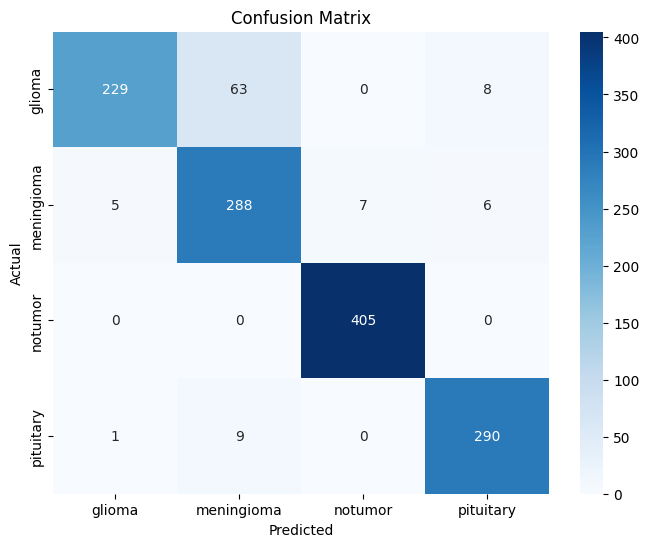

Classification Report:
               precision    recall  f1-score   support

      glioma       0.97      0.76      0.86       300
  meningioma       0.80      0.94      0.86       306
     notumor       0.98      1.00      0.99       405
   pituitary       0.95      0.97      0.96       300

    accuracy                           0.92      1311
   macro avg       0.93      0.92      0.92      1311
weighted avg       0.93      0.92      0.92      1311



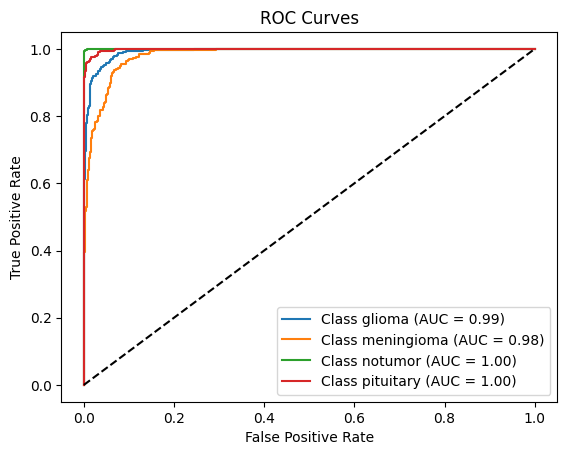

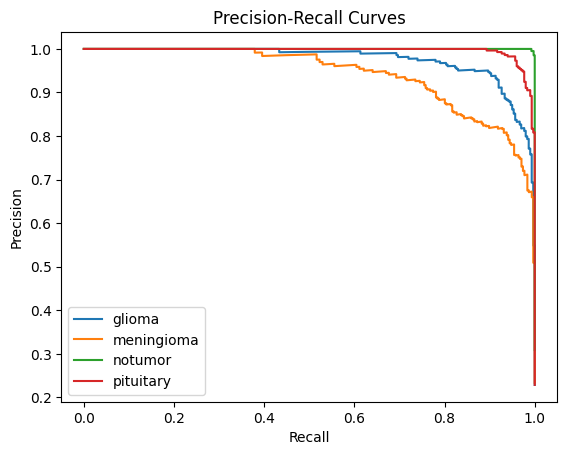

In [9]:
Y_pred_probs = model.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(Y_true, Y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:\n", classification_report(Y_true, Y_pred, target_names=labels))

# ROC Curve
for i in range(4):
    fpr, tpr, _ = roc_curve(Y_test[:, i], Y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f'Class {labels[i]} (AUC = {roc_auc_score(Y_test[:, i], Y_pred_probs[:, i]):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

# Precision-Recall Curve
for i in range(4):
    precision, recall, _ = precision_recall_curve(Y_test[:, i], Y_pred_probs[:, i])
    plt.plot(recall, precision, label=f'{labels[i]}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()


In [10]:
import numpy as np

# Get predictions
Y_pred_probs = model.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)
Y_true = np.argmax(Y_test, axis=1)

print(f"{'Index':<6}{'Shape':<14}{'Probability':<15}{'Predicted':<20}{'Actual':<20}{'Confidence':<12}{'Correct?':<10}")
print("-" * 95)

correct = 0
for i in range(len(X_test)):
    prob = np.max(Y_pred_probs[i])  # Get the highest probability (confidence)
    pred_label = labels[Y_pred[i]]
    true_label = labels[Y_true[i]]
    match = "✔️" if pred_label == true_label else "❌"
    if match == "✔️":
        correct += 1
    shape = str(X_test[i].shape)
    confidence = prob * 100  # Convert to percentage
    print(f"{i:<6}{shape:<14}{confidence:<14.2f}%{pred_label:<20}{true_label:<20}{confidence:<12.2f}%{match:<10}")

# Summary accuracy
accuracy = (correct / len(X_test)) * 100
print(f"\nOverall Accuracy on test set: {accuracy:.2f}%")


41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step
Index Shape         Probability    Predicted           Actual              Confidence  Correct?  
-----------------------------------------------------------------------------------------------
0     (224, 224, 3) 99.38         %glioma              glioma              99.38       %✔️        
1     (224, 224, 3) 72.00         %meningioma          glioma              72.00       %❌         
2     (224, 224, 3) 99.92         %glioma              glioma              99.92       %✔️        
3     (224, 224, 3) 80.69         %meningioma          glioma              80.69       %❌         
4     (224, 224, 3) 72.31         %glioma              glioma              72.31       %✔️        
5     (224, 224, 3) 50.98         %glioma              glioma              50.98       %✔️        
6     (224, 224, 3) 99.53         %glioma              glioma              99.53       %✔️        
7     (224, 224, 3) 100.00        %glioma              glioma            

41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step


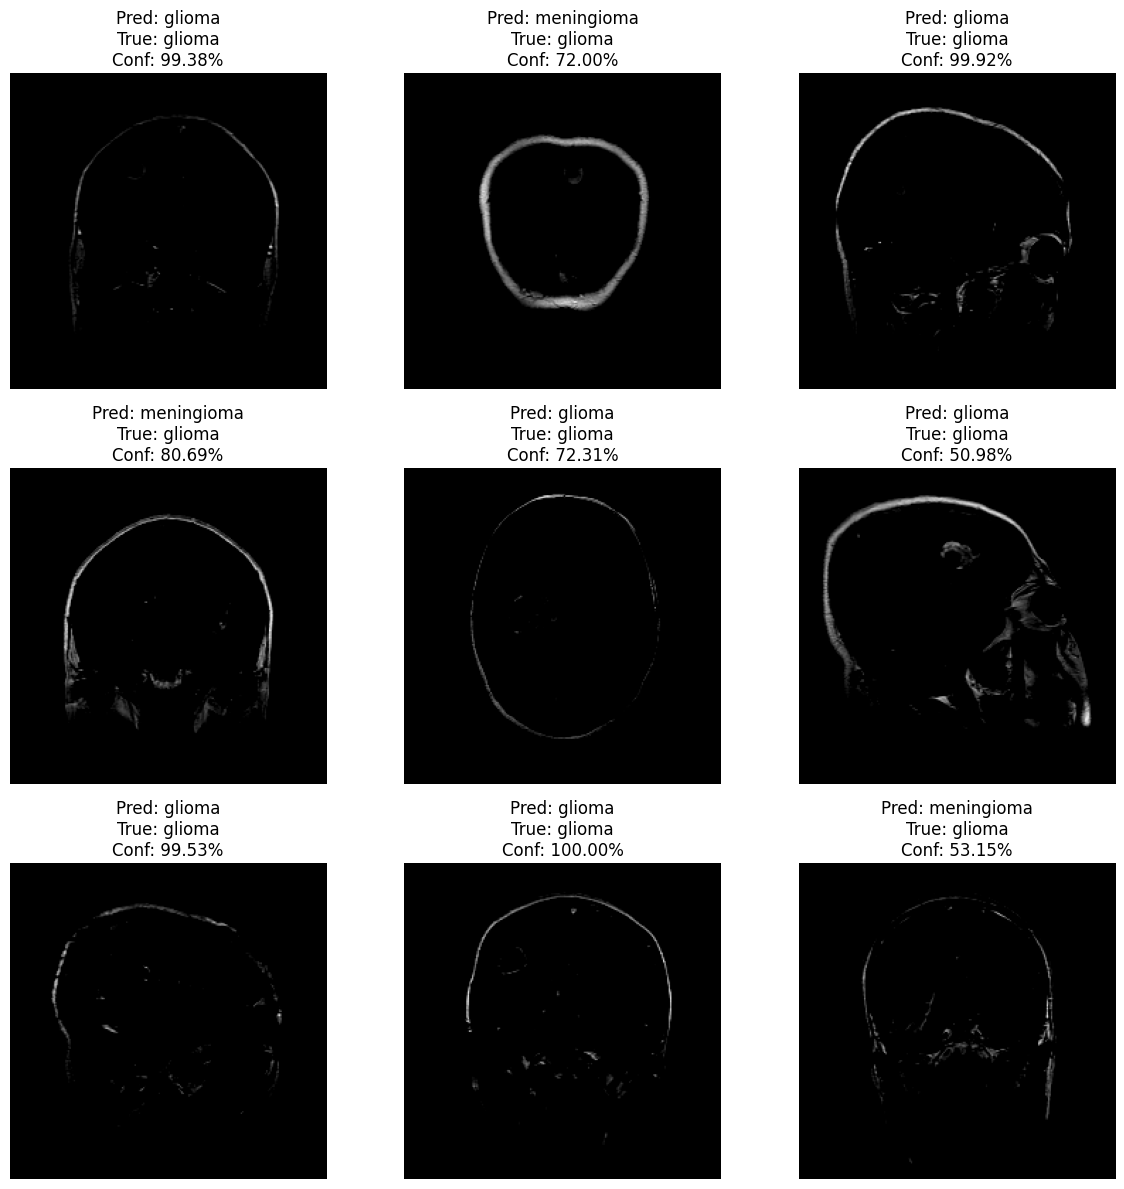

Overall Accuracy on the displayed images: 66.67%


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Number of images to display at once
num_images = 9  # Can be 6, 9, or any other number as required

# Get predictions
Y_pred_probs = model.predict(X_test)
Y_pred = np.argmax(Y_pred_probs, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Create a subplot grid
fig, axes = plt.subplots(3, 3, figsize=(12, 12))  # 3x3 grid for 9 images
axes = axes.flatten()

correct = 0
for i in range(num_images):
    prob = np.max(Y_pred_probs[i])  # Get the highest probability (confidence)
    pred_label = labels[Y_pred[i]]
    true_label = labels[Y_true[i]]
    match = "✔️" if pred_label == true_label else "❌"
    confidence = prob * 100  # Convert to percentage

    # If prediction is correct, increment correct count
    if match == "✔️":
        correct += 1
    
    # Plot the image
    axes[i].imshow(X_test[i])  # Show the image
    axes[i].set_title(f"Pred: {pred_label}\nTrue: {true_label}\nConf: {confidence:.2f}%")
    axes[i].axis('off')

# Show the plot with all images
plt.tight_layout()
plt.show()

# Summary accuracy
accuracy = (correct / num_images) * 100
print(f"Overall Accuracy on the displayed images: {accuracy:.2f}%")


In [12]:
IMG_SIZE = 224
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
label_dict = {k: v for v, k in enumerate(labels)}

def load_images(base_dir):
    X, Y = [], []
    for label in labels:
        path = os.path.join(base_dir, label)
        for img_file in tqdm(os.listdir(path), desc=f"Loading {label}"):
            img = cv2.imread(os.path.join(path, img_file))
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X.append(img)
            Y.append(label_dict[label])
    return np.array(X), to_categorical(Y)

# Load training and testing data
X_train, Y_train = load_images('/kaggle/input/tumor1/Training')
X_test, Y_test = load_images('/kaggle/input/tumor1/Testing')

# Print dataset shapes before normalization
print(f"Before Normalization:")
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

# Normalize
X_train = resnet_pre(X_train.astype(np.float32))
X_test = resnet_pre(X_test.astype(np.float32))

# Print dataset shapes after normalization
print(f"\nAfter Normalization:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


Loading pituitary: 100%|██████████| 300/300 [00:00<00:00, 435.87it/s]


Before Normalization:
X_train shape: (5712, 224, 224, 3)
Y_train shape: (5712, 4)
X_test shape: (1311, 224, 224, 3)
Y_test shape: (1311, 4)

After Normalization:
X_train shape: (5712, 224, 224, 3)
X_test shape: (1311, 224, 224, 3)


In [13]:
# Save Keras model
model.save("brain_tumor_model.h5")



In [14]:
# Convert to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save TFLite model
with open("brain_tumor_model.tflite", "wb") as f:
    f.write(tflite_model)


Saved artifact at '/tmp/tmpzkhls6bh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136348936926032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136348936928336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136348936926608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136348936928144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136348936922192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136348936927568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136348936929104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136347269482640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136347269481680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136347269482256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13634726948129

W0000 00:00:1745031034.355258      19 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1745031034.355300      19 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1745031034.747606      19 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
